**Importing relevant libraries and Pickel Data**

In [49]:
## Importing libraries and packages 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import pickle
import math
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import GridSearchCV
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

In [50]:
import os
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
import tensorflow as tf
tf.__version__
from tensorflow.keras import layers, models

In [51]:
# Open Training pkl file
with open('data/train_data.pkl', 'rb') as f:
    data = pickle.load(f)

# Loading Image and Labels Training Data
images_train = data['images']
labels_train = data['labels']

# Opening Test Data Set 
with open('data/test_data.pkl', 'rb') as g:
    data = pickle.load(g)

images_test = data['images']





**Exploring Pre-November 30th Data**

In [52]:
print("This is the outline of the images training data: ", images_train)
print("This is the outline of the label training data", labels_train)

This is the outline of the images training data:  [[[[ 6  4  0]
   [ 9  5  0]
   [ 8  4  0]
   ...
   [ 9  6  0]
   [ 9  6  0]
   [ 7  4  0]]

  [[11  6  0]
   [ 4  4  0]
   [ 3  3  0]
   ...
   [ 9  6  0]
   [ 6  4  0]
   [ 4  2  0]]

  [[11  6  0]
   [ 4  4  0]
   [ 3  3  0]
   ...
   [ 6  4  0]
   [ 6  4  0]
   [ 4  2  0]]

  ...

  [[ 1  1  0]
   [ 0  0  0]
   [ 0  0  1]
   ...
   [ 5  4  0]
   [ 6  5  0]
   [ 6  5  0]]

  [[ 3  1  1]
   [ 0  0  0]
   [ 0  0  1]
   ...
   [ 6  5  0]
   [ 6  5  0]
   [ 7  6  0]]

  [[10  2  2]
   [ 0  0  1]
   [ 0  0  1]
   ...
   [ 6  5  0]
   [ 7  6  0]
   [ 7  6  0]]]


 [[[11  9  0]
   [ 9  7  0]
   [ 9  7  0]
   ...
   [ 0  0  1]
   [ 0  0  1]
   [ 0  0  1]]

  [[12  9  0]
   [11  7  0]
   [ 9  6  0]
   ...
   [ 0  0  2]
   [ 0  0  1]
   [ 0  0  1]]

  [[ 9  7  0]
   [12  8  0]
   [10  6  0]
   ...
   [ 0  0  1]
   [ 0  0  1]
   [ 0  0  0]]

  ...

  [[ 0  0  3]
   [ 0  0  3]
   [ 0  0  4]
   ...
   [ 0  0  2]
   [ 0  0  1]
   [ 0  0  0]]

  [[

In [53]:
## Exploring shape of the data 
print("This is the shape of the images training data: ", images_train.shape)
print("This is the shape of the label training data", labels_train.shape)
print("This is the shape of the images test data: ", images_test.shape)

## Exploring data type 
print("This is the data type of the image training: ", images_train.dtype)
print("This is the number of unique value for labels training: ", np.unique(labels_train))
print("This is the data type of the image test: ", images_test.dtype)

This is the shape of the images training data:  (1080, 28, 28, 3)
This is the shape of the label training data (1080, 1)
This is the shape of the images test data:  (400, 28, 28, 3)
This is the data type of the image training:  uint8
This is the number of unique value for labels training:  [0 1 2 3 4]
This is the data type of the image test:  uint8


In [54]:
# Seeing class breakdown for labels 
unique, counts = np.unique(labels_train, return_counts=True)
print("Class distribution:")
for u, c in zip(unique, counts):
    print(f"Label {u}: {c} samples")

Class distribution:
Label 0: 486 samples
Label 1: 128 samples
Label 2: 206 samples
Label 3: 194 samples
Label 4: 66 samples


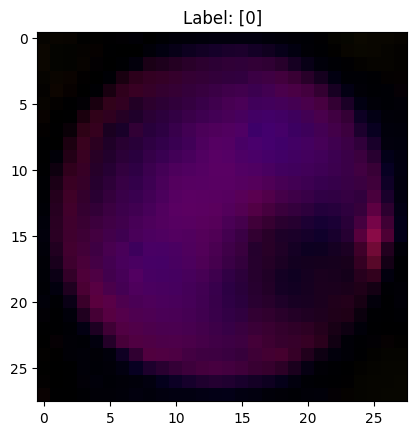

In [55]:
# Plotting Graph to visualize images
plt.imshow(images_train[0], cmap="gray")
plt.title(f"Label: {labels_train[0]}")
plt.show()

In [56]:
print(" The minimum pixel for training: ", images_train.min())
print(" The maximum pixel for training: ", images_train.max())
print(" The Mean pixel for training: ", images_train.mean())
print(" The standard deviation for training: ", images_train.std())

print(" The minimum pixel for test: ", images_test.min())
print(" The maximum pixel for test: ", images_test.max())
print(" The Mean pixel for test: ", images_test.mean())
print(" The standard deviation for test: ", images_test.std())

 The minimum pixel for training:  0
 The maximum pixel for training:  255
 The Mean pixel for training:  37.74362638573948
 The standard deviation for training:  45.53972858040953
 The minimum pixel for test:  0
 The maximum pixel for test:  255
 The Mean pixel for test:  36.420057397959184
 The standard deviation for test:  44.014485738716104


**Investigating Missing Data**

In [57]:
print("The number of missing values in the images training dataset: ", np.isnan(images_train).sum())
print("The number of missing values in the images testing dataset: ", np.isnan(images_test).sum())

The number of missing values in the images training dataset:  0
The number of missing values in the images testing dataset:  0


**Removing Outlier Values and Low Variance Images**

In [58]:
# Removing outliers that are key for Logistic Regression and KNN
pixel_sums = images_train.sum(axis=(1,2,3))

# Calculating lower and higher percentiles 
lowp = np.percentile(pixel_sums, 0.5)
highp = np.percentile(pixel_sums, 99.5)

# mask to help remove outliers 
mask_outlier = (pixel_sums > lowp) & (pixel_sums < highp)

# Plotting images 
images_train_clean = images_train[mask_outlier]
labels_train_clean = labels_train[mask_outlier]

# Seeing how much was removed after outlier and variance removal 
print("Original images count:", len(images_train_clean))
print("After images cleaning:", len(images_train_clean))
print("Original Labels count", len(labels_train))
print("Labels count after being cleaned", len(labels_train_clean))
print("Images Removed:", len(images_train) - len(images_train_clean))
print("Labels Removed",  len(labels_train) - len(labels_train_clean))

Original images count: 1068
After images cleaning: 1068
Original Labels count 1080
Labels count after being cleaned 1068
Images Removed: 12
Labels Removed 12


In [59]:
# Removing low variance images that are below a certain threshold 
var = images_train_clean.var(axis=(1,2,3))
low_var_thresh = np.percentile(var, 1)
mask_var = var > low_var_thresh
images_train_updated = images_train_clean[mask_var]
labels_train_updated = labels_train_clean[mask_var]

print("Number of images post low var removal: ", len(images_train_updated))
print("Number of labels post low var removal: ", len(labels_train_updated))

Number of images post low var removal:  1057
Number of labels post low var removal:  1057


**Reshaping & Standardizing Data**

In [60]:
# Reshaping training and test data so we can perform Classification Methods 
images_train_rs = images_train_updated.reshape(images_train_updated.shape[0], -1)
y = labels_train_updated.reshape(-1)
images_test_rs = images_test.reshape(images_test.shape[0], -1)

# Performing Normalization on images 
X = images_train_rs/255.0
X_test = images_test_rs/255.0



**Train Test Split**

In [61]:
# Defining Train Test Split function as similar as possible to sklearn
def train_valid_split(X, y, test_size=0.2, random_state=42):
    # Defining random number generator 
    rng = np.random.RandomState(random_state)
    # Defining number of samples and indices 
    n_samples = len(X)
    indices = np.arange(n_samples)
    
    # shuffle in-place exactly like sklearn does
    rng.shuffle(indices)
    
    # Defining test number, test index, and train index 
    n_test = math.ceil(n_samples * test_size)
    test_idx = indices[:n_test]
    train_idx = indices[n_test:]
    
    # Return X and y train and test data 
    return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

# Calling train_valid split function
X_tr, X_val, y_tr, y_val = train_valid_split(X, y)
# Print number of features and labels 
print("\n These are the features for X_trained here: ", X_tr)
print("\n These are the labels for y_trained here: ", y_tr)


 These are the features for X_trained here:  [[1.         0.25882353 0.26666667 ... 1.         0.24705882 0.28235294]
 [0.02352941 0.01176471 0.         ... 0.01960784 0.01176471 0.        ]
 [0.08627451 0.05882353 0.         ... 0.03921569 0.02745098 0.        ]
 ...
 [0.05882353 0.03529412 0.         ... 0.01176471 0.00784314 0.        ]
 [0.06666667 0.03529412 0.         ... 0.02352941 0.01960784 0.        ]
 [0.05490196 0.03137255 0.         ... 0.01176471 0.00392157 0.        ]]

 These are the labels for y_trained here:  [1 1 3 2 0 0 2 1 3 3 0 0 0 0 2 3 3 0 0 0 1 2 3 4 0 2 1 3 0 0 0 0 0 3 3 4 4
 3 1 1 2 0 0 1 3 0 0 0 0 2 0 0 0 0 3 4 2 0 0 1 1 2 2 4 0 2 1 0 2 4 3 1 3 3
 3 2 0 0 1 0 0 4 3 2 0 0 1 0 0 1 3 1 0 0 0 3 0 2 1 0 4 3 2 3 0 2 0 0 2 3 2
 0 3 2 3 0 0 0 0 0 0 3 4 2 0 0 2 3 4 0 3 2 1 0 2 0 2 2 0 2 1 3 0 1 0 0 0 3
 0 4 1 3 2 0 3 0 2 0 3 2 3 2 3 2 0 2 3 2 0 0 0 3 0 0 0 0 3 2 0 0 2 0 0 2 0
 0 0 0 2 3 3 3 3 4 1 0 3 0 0 2 2 0 3 0 0 4 2 0 3 4 3 2 0 3 0 3 0 3 2 1 2 1
 0 4 0 4 0 2 0 0

**Pre November 30th KNN Model Testing**
This method fails to beat the Kaggle baseline, the kaggle score is around 43%.  

In [62]:
# KNN pre November 30th

# L2 Normalization function for Cosine KNN
# Cosine KNN is more advantageous than classical KNN for high dimensional image data sets
def l2_norml(X):
    # Defining norms
    norms = np.linalg.norm(X, axis=1, keepdims=True) + 1e-8
    # returning X/norms 
    return X/norms

# Defining X_tr_norm, X_val_norm, and X_test_norm 
X_tr_norm = l2_norml(X_tr)
X_val_norm = l2_norml(X_val)
X_test_norm = l2_norml(X_test)


# Defining KNN for images which will include cosine similarity acting in conjunction with Weighted Voting
def knn_predict(X_tr_norm, y_train, X_test_norm, k):
    # Defining predictions array and length of prediction
    preds = []
    K = len(np.unique(y_train))
    # Iterating through X_test_norm
    for x in X_test_norm:
        # Defining cosine similarity between points 
        siml = X_tr_norm @ x   
        # Sorting by the top-k neighbors 
        idx = np.argsort(-siml)[:k]   
        # Defining the neighbor labels                         
        n_labels = y_train[idx]
        # Defining weights based on similarity
        wts = siml[idx] + 1e-8
        # Defining votes for label initially as array of zeros 
        vote = np.zeros(K)
        # Defining weight for label
        for lbl, w in zip(n_labels, wts):
            vote[lbl] += w
        # Appending votes to predictions 
        preds.append(np.argmax(vote))
    # Returning prediction arrays 
    return np.array(preds)

# Defining range of k hyperparameters 
k_values = [3, 5, 7, 9, 11, 13, 15, 17, 19, 21, 23, 25, 27, 29, 31]
results = {}

# Iterating through k_values
for k in k_values:
    # Defining knn y label predictions 
    y_pred_knn = knn_predict(X_tr_norm, y_tr, X_val_norm, k)
    # Defining accuracy and results 
    acc = np.mean(y_pred_knn == y_val)
    results[k] = acc
    print(f"k={k}, accuracy={acc:.4f}")

# Select the best performing k
optimal_k = max(results, key=results.get)
optimal_acc = results[optimal_k]

# Print Statement for best performing k
print(f"The best performing k = {optimal_k}  (Accuracy = {optimal_acc:.4f})")

# Retraining the KNN on full training set to optimally predicting test
# Normalizing the full L2 datasets for COSINE KNN
X_norm = l2_norml(X)
X_test_norm = l2_norml(X_test)
y_pred_test_knn = knn_predict(X_norm, y, X_test_norm, k=optimal_k)

# Saving the Kaggle submission
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test_knn) + 1),
    "Label": y_pred_test_knn
})

# Generating KNN Submission file for kaggle 
df_sub.to_csv("KNN_submission_11252025.csv", index=False)

# Output print statement indicating optimal Kaggle file was created successfully 
print(f"Kaggle submission saved using k={optimal_k} !")


k=3, accuracy=0.4528
k=5, accuracy=0.4858
k=7, accuracy=0.4670
k=9, accuracy=0.4575
k=11, accuracy=0.4575
k=13, accuracy=0.4481
k=15, accuracy=0.4481
k=17, accuracy=0.4387
k=19, accuracy=0.4623
k=21, accuracy=0.4528
k=23, accuracy=0.4528
k=25, accuracy=0.4528
k=27, accuracy=0.4623
k=29, accuracy=0.4670
k=31, accuracy=0.4717
The best performing k = 5  (Accuracy = 0.4858)
Kaggle submission saved using k=5 !


**Pre November 30th Logistic Regression Model Testing**


In [63]:
# Defining Binary Logistic Regression Class which will be later used in Multiclass Logistis Regression
class LR:
  # Defining Contructor for function, key inputs are learning rate and max_iterations 
  def __init__(self, lrate=0.01, miter=1000):
    self.lrate = lrate
    self.miter = miter
    self.weights = None
    self.bias = None
  
  # Defining Sigmoid function for Logistic Regression
  def sigmoid(self, z):
    # Returning sigmoid function
    return 1 / (1 + np.exp(-z))
  # Defining fit function for X and y training data 
  def fit(self, X, y):
    # Reshaping Y 
    y = y.reshape(-1)
    # Defining number of samples and features based on X.shape
    n_samples, n_features = X.shape
    # Defining self.weights 
    self.weights = np.zeros(n_features)
    # Defining bias 
    self.bias = 0
    
    # Iterating through max iters
    for _ in range(self.miter):
      # Defining linear model and y_predictions using sigmoid functions
      lin_model = np.dot(X, self.weights) + self.bias
      # Defining y_predictions 
      y_pred = self.sigmoid(lin_model)
      
      # Gradients (binary cross-entropy loss)
      # Defining error for predictions compared to real y class
      error = y_pred - y
      # Defining change in weights and bias 
      deltaw = (1 / n_samples) * np.dot(X.T, error)
      deltab = (1 / n_samples) * np.sum(error)
      # Updating weights and bias 
      self.weights -= self.lrate * deltaw
      self.bias -= self.lrate * deltab
  # Defining prediction probabilities 
  def predict_probas(self, X):
    # Defining lin model via weights and bias
    lin_model = np.dot(X, self.weights) + self.bias
    # Returning sigmoid function of lin_model 
    return self.sigmoid(lin_model)
  
  # Defining predictions 
  def predict(self, X, threshold=0.5):
    # Defining y_pred_probas with previously defined function
    y_pred_probas = self.predict_probas(X)
    # Returning y_pred_probas which are bigger than a given threshold 
    return (y_pred_probas >= threshold).astype(int)
  

**The Logistic Regression model below beats the baseline with Kaggle score of around 50%**

In [64]:
# Defining Multiclass Logistic Regression
class MCLR:
  # Defining the constructor
  def __init__(self, lrate=0.01, miter=10000):
    self.lrate = lrate
    self.miter = miter
    self.classifiers = {}
    self.classes = None
  # Defining fit function
  def fit(self, X, y):
    self.classes = np.unique(y)
    self.classifiers = {}
    
    # Defining c in self.classes_
    for c in self.classes:
      # Defining y_binary 
      y_bin = (y == c).astype(int)
      # Calling previously defined logistic regression function 
      clf = LR(lrate=self.lrate,
                               miter=self.miter)
      # Fitting classifier on X and y_binary 
      clf.fit(X, y_bin)
      self.classifiers[c] = clf
  
  # Defining probabilities for class 
  def predict_probas(self, X):
    # Defining probabilities
    probs = np.column_stack([
      self.classifiers[c].predict_probas(X) for c in self.classes
    ])
    #  ret
    return probs
  
  # Predicting given multi class
  def predict(self, X):
    probs = self.predict_probas(X)
    return self.classes[np.argmax(probs, axis=1)]
  
  # Defining accuracy score 
  def score(self, X, y):
    y_pred = self.predict(X)
    return np.mean(y_pred == y)
  
# Training the model
model = MCLR(lrate=0.01, miter=12000)
#model = MCLR(lrate=0.01, miter=10000)
model.fit(X_tr, y_tr)

# Defining Validation Accuracy 
val_acc = model.score(X_val, y_val)
print("Multi Class Logistic Regression Validation Accuracy:", val_acc)

# 6. Predictions on the test set used to generate Kaggle file 
y_pred_test = model.predict(X_test)

# Create submission file for Kaggle 
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

df_sub.to_csv("logreg_multiclass_submission_12032025.csv", index=False)
print("Kaggle file saved as logreg_multiclass_12032025_submission.csv")



Multi Class Logistic Regression Validation Accuracy: 0.47641509433962265
Kaggle file saved as logreg_multiclass_12032025_submission.csv


**Logistic Regression Model with given hyperparameter combination below beats the Kaggle baseline with score 51%**

In [65]:
# Hyperparameter Tuning
# Test different combinations of learning rates and maximum iterations 
lrates = [0.001, 0.003, 0.005, 0.01]
miters = [3000, 5000, 8000, 10000]

# Defining Hyperparameter Tuning results array 
hypt_results = []


print("\nConducting the Hyperparameter Search, stay tuned...\n")
# Iterating through Learning Rates and iterations
for lr in lrates:
    for iter in miters:
        model = MCLR(lrate=lr, miter=iter)
        # Fit model against X_tr and y_tr
        model.fit(X_tr, y_tr)
        # Calculating validation accuracy 
        acc_val = model.score(X_val, y_val)
        # Hyperparameter results appended to the array 
        hypt_results.append((lr, iter, acc_val))
        print(f"LR={lr}, MaxIter={iter} has Val Acc = {acc_val:.4f}")

# Selecting the best results combination
ordered_results = sorted(hypt_results, key=lambda x: x[2], reverse=True)

# Defining optimal_lr, optimal_iterations, and accuracy 
optimal_lr, optimal_it, optimal_acc = ordered_results[0]
print(f" The best hyperparameters found are as follows:")
print(f"   learning_rate = {optimal_lr}")
print(f"   max_iter      = {optimal_it}")
print(f"   val_accuracy  = {optimal_acc:.4f}")

# Retrain the optimal model on the full data set
optimal_model = MCLR(lrate=optimal_lr, miter=optimal_it)
optimal_model.fit(X, y)

# Predict test set
y_pred_test = optimal_model.predict(X_test)

# Create Kaggle submission file for hyperparameter tuned data 
df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

file = f"logreg_ovr_tuned_lr{optimal_lr}_iter{optimal_it}_12032025.csv"
df_sub.to_csv(file, index=False)
print(f"Kaggle file saved as {file}")



Conducting the Hyperparameter Search, stay tuned...

LR=0.001, MaxIter=3000 has Val Acc = 0.4292
LR=0.001, MaxIter=5000 has Val Acc = 0.4481
LR=0.001, MaxIter=8000 has Val Acc = 0.4575
LR=0.001, MaxIter=10000 has Val Acc = 0.4623
LR=0.003, MaxIter=3000 has Val Acc = 0.4670
LR=0.003, MaxIter=5000 has Val Acc = 0.4764
LR=0.003, MaxIter=8000 has Val Acc = 0.4623
LR=0.003, MaxIter=10000 has Val Acc = 0.4670
LR=0.005, MaxIter=3000 has Val Acc = 0.4764
LR=0.005, MaxIter=5000 has Val Acc = 0.4623
LR=0.005, MaxIter=8000 has Val Acc = 0.4623
LR=0.005, MaxIter=10000 has Val Acc = 0.4717
LR=0.01, MaxIter=3000 has Val Acc = 0.4670
LR=0.01, MaxIter=5000 has Val Acc = 0.4717
LR=0.01, MaxIter=8000 has Val Acc = 0.4717
LR=0.01, MaxIter=10000 has Val Acc = 0.4811
 The best hyperparameters found are as follows:
   learning_rate = 0.01
   max_iter      = 10000
   val_accuracy  = 0.4811
Kaggle file saved as logreg_ovr_tuned_lr0.01_iter10000_12032025.csv


**Pre November 30th Multiclass SVM Classification Model Testing**
This method fails to beat the Kaggle baseline, its accuracy is around 43%

In [66]:
# Defining Multiclass SVM Implementation model
def svm_train_mc(X, y, lr=0.0007, C=1.0, epochs=1500):
    # Defining Number and Dimensions of SVM
    Num, Dim = X.shape
    # Defining K as number of unique classes 
    K = len(np.unique(y))
    # Defining Weights and Biases
    Weights = np.zeros((K, Dim))
    b = np.zeros(K)
    
    # Iterating the number of classes in K
    for clss in range(K):
        # Convert the class to binary classification
        y_binary = np.where(y == clss, 1, -1)
        # Defining w and bias 
        w = np.zeros(Dim)
        bias = 0
        # Iterating through epochs 
        for epoch in range(epochs):
            # Defining scores and margins 
            scores = X @ w + bias
            margins = 1 - y_binary * scores

            # Defining the Hinge Loss Indicator
            indic = (margins > 0).astype(float)

            # Defining the Gradients for SVM
            delta_w = w - C * (X * (indic * y_binary)[:, None]).mean(axis=0)
            delta_b = -C * (indic * y_binary).mean()

            # Updating Weights and bias 
            w -= lr * delta_w
            bias -= lr * delta_b

            # Printing loss for class 0 specifically 
            if clss == 0 and epoch % 400 == 0:
                loss = np.maximum(0, margins).mean() + 0.5 * np.sum(w * w)
                print(f"Class {clss} | Epoch {epoch}, Loss={loss:.4f}")

        Weights[clss] = w
        b[clss] = bias
    # Returning Weights and b 
    return Weights, b

# Defining SVM Prediction for multiclass 
def svm_predict_mc(X, W, b):
    prediction_scores = X @ W.T + b
    return np.argmax(prediction_scores, axis=1)

# Defining hyperparameters to test SVM
l_rates = [0.0004]
C_values = [1.0, 2.0]
epochs_ = [1200, 1800]

# Defining best accuracy, parameters, and model
op_acc = 0
op_params = None
op_model = None

# Priting multiclass SVM statement 
print("\n Results of the Multiclass SVM Hyperparameter Search: ")

# Iterating through hyperparameters 
for lr in l_rates:
    for C in C_values:
        for ep in epochs_:
            print(f"\nTesting: LR={lr}, C={C}, epochs={ep}")

            W_svm, b_svm = svm_train_mc(
                X_tr, y_tr,
                lr=lr,
                C=C,
                epochs=ep
            )

            y_pred_svm = svm_predict_mc(X_val, W_svm, b_svm)
            acc = np.mean(y_pred_svm == y_val)

            print(f"→ Validation Accuracy = {acc:.4f}")
            # Updating accuracy and other parameters 
            if acc > op_acc:
                op_acc = acc
                op_params = (lr, C, ep)
                op_model = (W_svm, b_svm)

# Printing out best SVM
print("\nThe BEST SVM Results are as follows:")
print("The Best LR =", op_params[0])
print("The Best C =", op_params[1])
print("The Best Epochs =", op_params[2])
print("The Best Accuracy =", op_acc)

# Generating Test Set Predictions 
W_best, b_best = op_model
y_pred_test = svm_predict_mc(X_test, W_best, b_best)

df_sub = pd.DataFrame({
    "ID": np.arange(1, len(y_pred_test) + 1),
    "Label": y_pred_test
})

df_sub.to_csv("svm_submission_11252025.csv", index=False)
print("\nKaggle submission saved as svm_submission.csv")


 Results of the Multiclass SVM Hyperparameter Search: 

Testing: LR=0.0004, C=1.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9458
Class 0 | Epoch 800, Loss=0.9258
→ Validation Accuracy = 0.4292

Testing: LR=0.0004, C=1.0, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9458
Class 0 | Epoch 800, Loss=0.9258
Class 0 | Epoch 1200, Loss=0.9109
Class 0 | Epoch 1600, Loss=0.8996
→ Validation Accuracy = 0.4292

Testing: LR=0.0004, C=2.0, epochs=1200
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9229
Class 0 | Epoch 800, Loss=0.8929
→ Validation Accuracy = 0.4292

Testing: LR=0.0004, C=2.0, epochs=1800
Class 0 | Epoch 0, Loss=1.0000
Class 0 | Epoch 400, Loss=0.9229
Class 0 | Epoch 800, Loss=0.8929
Class 0 | Epoch 1200, Loss=0.8759
Class 0 | Epoch 1600, Loss=0.8702
→ Validation Accuracy = 0.4340

The BEST SVM Results are as follows:
The Best LR = 0.0004
The Best C = 2.0
The Best Epochs = 1800
The Best Accuracy = 0.433962264150943

**Post November 30th Model Evaluation**

**Train Test Split with SKlearn**

In [67]:
X_tr_sk, X_val_sk, y_tr_sk, y_val_sk = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Training Shape is: ", X_tr_sk.shape)
print("Test Shape is: " , X_val_sk.shape)

Training Shape is:  (845, 2352)
Test Shape is:  (212, 2352)


**Training Logistic Regression sklearn**

Note method beats the Kaggle baseline, highest accuracy score is 51.5%

Fitting 3 folds for each of 32 candidates, totalling 96 fits


c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Best Logistic Regression Params: {'C': 0.1, 'class_weight': None, 'max_iter': 3000, 'penalty': 'l2', 'solver': 'lbfgs'}

Validation Accuracy: 0.4528
Validation Error: 0.5472

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.54      0.79      0.64        96
           1       0.17      0.04      0.07        24
           2       0.20      0.17      0.18        41
           3       0.39      0.32      0.35        38
           4       0.00      0.00      0.00        13

    accuracy                           0.45       212
   macro avg       0.26      0.26      0.25       212
weighted avg       0.37      0.45      0.40       212



c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

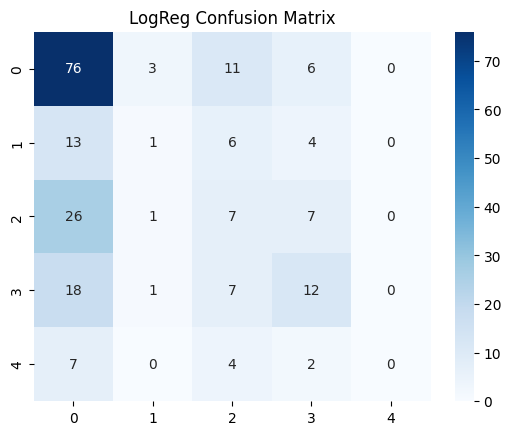

c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(



Saved logreg_sklearn_submission.csv!


In [68]:
# Defining logistic regression with Sklearn 
def logreg_train(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk):
    # Hyperparameter Tuning, use similar hyperparameters as pre November 30th
    # Selecting C, solver, penalty, and max_iter
    # First set up a try block
    try:
        grid_param = {
            'C': [0.001, 0.01, 0.1, 1],
            'solver': ['lbfgs'],
            'penalty': ['l2'],
            'max_iter': [3000, 5000, 8000, 10000],
            "class_weight": ["balanced", None]
}

       # Defining multiclass Log reg
        model = LogisticRegression(multi_class='ovr')
       # Defining Grid Search
       # Selecting 3 as the cross validation number
        grid = GridSearchCV(
            model, grid_param, cv=3, scoring='accuracy',
            n_jobs=-1, verbose=2
        )
        # Fitting the param_grid
        grid.fit(X_tr_sk, y_tr_sk)
       # Printing Best Log Reg parameters and generating prediction off of best
        print("\nBest Logistic Regression Params:", grid.best_params_)
        
        # Defining best param grid estimator 
        best = grid.best_estimator_
        y_pred = best.predict(X_val_sk)

        # Defining validation report and error 
        val_acc = best.score(X_val_sk, y_val_sk)
        val_error = 1 - val_acc
        # Printing Validation Accuracy and Error 
        print(f"\nValidation Accuracy: {val_acc:.4f}")
        print(f"Validation Error: {val_error:.4f}")
        # Printing Validation Classification Report 
        print("\nValidation Classification Report:")
        print(classification_report(y_val_sk, y_pred))
        # Generating Confusion Matrix 
        cm = confusion_matrix(y_val_sk, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
        plt.title("LogReg Confusion Matrix")
        plt.show()

        # Predicting test Logistic Regression
        # Fitting on entire training set 
        best_param_full_ds = LogisticRegression(
            **grid.best_params_, multi_class="ovr"
        ).fit(X, y)
        
        # Y_test_pred
        y_test_pred = best_param_full_ds.predict(X_test)
        
        # Defining Kaggle Submission DF
        pd.DataFrame({
            "ID": np.arange(1, len(y_test_pred)+1),
            "Label": y_test_pred
        }).to_csv("logreg_sklearn_postNov30_submission.csv", index=False)
       # Saving Submission
        print("\nSaved logreg_sklearn_submission.csv!")
    # Catching exceptions
    except Exception as e:
        print(" There is an error in Logistic Regression:", str(e))

# Calling logreg_train
logreg_train(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk)

    

**Post November 30th Random Forest Model**

Does not beat Kaggle baseline, Kaggle accuracy score is 44.5% 


The Random Forest Grid is running
Fitting 3 folds for each of 144 candidates, totalling 432 fits

Best Random Forest Params: {'class_weight': None, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}

The Validation Accuracy is: 0.4623
The Validation Error is:   0.5377

The Validation Classification Report is:
              precision    recall  f1-score   support

           0       0.62      0.75      0.68        96
           1       0.42      0.21      0.28        24
           2       0.27      0.29      0.28        41
           3       0.23      0.24      0.23        38
           4       0.00      0.00      0.00        13

    accuracy                           0.46       212
   macro avg       0.31      0.30      0.29       212
weighted avg       0.42      0.46      0.43       212



c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no 

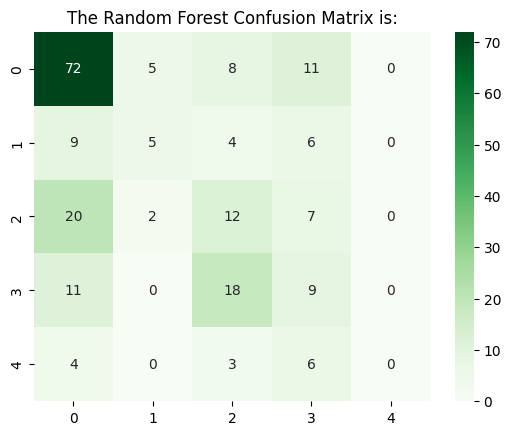


Saved random_forest_postNov30_submission.csv!


In [69]:
# Defining function for Random Forest
def train_rf(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk):
    try:
        # Defining hyper parameter grid for RF including estimators, depth, feaures, weight
        param_grid = {
            'n_estimators': [200, 400, 600],
            'max_depth': [10, 20, 30],
            'max_features': ['sqrt', 'log2'],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2],
            'class_weight': [None, 'balanced']
        }
        # Defining Model and RFC
        model = RandomForestClassifier(n_jobs=-1, random_state=42)
        # Defining Grid Search CV
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            scoring='accuracy',
            cv=3,
            verbose=2,
            n_jobs=-1
        )
        # Defining RF Grid 
        print("\nThe Random Forest Grid is running")
        grid.fit(X_tr_sk, y_tr_sk)
        # Printing best RF parameters
        print("\nBest Random Forest Params:", grid.best_params_)
        # Printing best estimator 
        best = grid.best_estimator_

        # Validation predictions
        y_pred = best.predict(X_val_sk)

        # Defining Validation accuracy and error
        val_acc = best.score(X_val_sk, y_val_sk)
        val_error = 1 - val_acc

        print(f"\nThe Validation Accuracy is: {val_acc:.4f}")
        print(f"The Validation Error is:   {val_error:.4f}")

        # Defining Classification report
        print("\nThe Validation Classification Report is:")
        print(classification_report(y_val_sk, y_pred))

        # Confusion matrix
        cm = confusion_matrix(y_val_sk, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap="Greens")
        plt.title("The Random Forest Confusion Matrix is:")
        plt.show()

        # Fitting the best Random Forest on the full dataset
        best_params_full_ds = RandomForestClassifier(
            **grid.best_params_, n_jobs=-1, random_state=42
        ).fit(X, y)

        # Testing the predictions
        y_test_pred = best_params_full_ds.predict(X_test)

        # Kaggle submission
        pd.DataFrame({
            "ID": np.arange(1, len(y_test_pred) + 1),
            "Label": y_test_pred
        }).to_csv("random_forest_postNov30_submission.csv", index=False)

        print("\nSaved random_forest_postNov30_submission.csv!")

       # returning validation accuracy and error 
        return val_acc, val_error

    except Exception as excep:
        print("There is an error in Random Forest model:", str(excep))


# Calling the RF function
acc_rf, err_rf = train_rf(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk)



**Defining MLP Model Post November 30th**
This model beats the Kaggle baseline, the kaggle score is 47.5%


MLP Grid Search is running
Fitting 3 folds for each of 6 candidates, totalling 18 fits

The Best MLP Params: {'alpha': 0.0001, 'hidden_layer_sizes': (128,), 'learning_rate_init': 0.001, 'max_iter': 30}

Validation Accuracy: 0.4575
Validation Error:   0.5425

Validation Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.77      0.69        96
           1       0.33      0.08      0.13        24
           2       0.18      0.17      0.18        41
           3       0.31      0.29      0.30        38
           4       0.23      0.23      0.23        13

    accuracy                           0.46       212
   macro avg       0.34      0.31      0.31       212
weighted avg       0.42      0.46      0.43       212



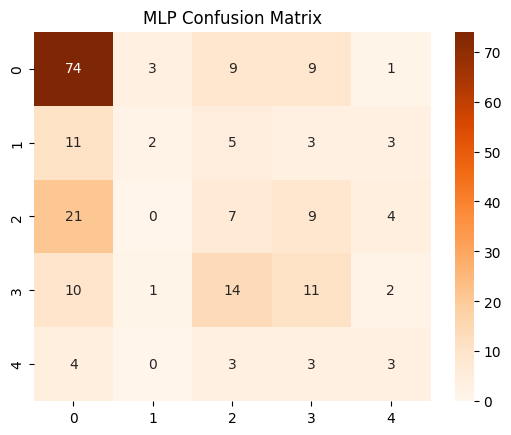


Saved mlp_postNov30_sklearn_submission.csv!


c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


In [70]:
# Defining MLP model
def train_mlp(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk):
    # Defining relevant hyperparameters 
    try:
        # Scaling data for MLP to ensure the model is as accurate as possible 
        scaler = StandardScaler()
        X_tr_scaled = scaler.fit_transform(X_tr_sk)
        X_val_scaled = scaler.transform(X_val_sk)          

        # Hyperparameters optimized for small image sets 
        # Selecting smaller hidden layer and small learning rates to avoid overfitting 

        param_grid = {
            "hidden_layer_sizes": [(64,), (128,)],
            "alpha": [1e-4],
            "learning_rate_init": [1e-3],
            "max_iter": [30, 50, 70]
        }

        # Defining Model for MLP, selected activation as relu, solver as adam 
        # Setting early stopping to be true in order to prevent overfitting 
        model = MLPClassifier(
            activation="relu",
            solver="adam",
            batch_size=32,
            early_stopping=True,         
            validation_fraction=0.1,      
            random_state=42
        )

        # Defining Grid
        grid = GridSearchCV(
            estimator=model,
            param_grid=param_grid,
            cv=3,
            scoring="accuracy",
            n_jobs=-1,
            verbose=2
        )

        # Defining MLP Grid Search
        print("\nMLP Grid Search is running")
        grid.fit(X_tr_scaled, y_tr_sk)

        # Defining Best MLP Hyperparameters 
        print("\nThe Best MLP Params:", grid.best_params_)
        
        best = grid.best_estimator_
        y_pred = best.predict(X_val_scaled)

        # Defining Validation metrics
        val_acc = best.score(X_val_scaled, y_val_sk)
        val_error = 1 - val_acc

        print(f"\nValidation Accuracy: {val_acc:.4f}")
        print(f"Validation Error:   {val_error:.4f}")

        # Defining Classification Report and Confusion Matrix 
        print("\nValidation Classification Report:")
        print(classification_report(y_val_sk, y_pred))

        # Generating the Confusion matrix
        cm = confusion_matrix(y_val_sk, y_pred)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
        plt.title("MLP Confusion Matrix")
        plt.show()

        # Scaling the Full Data Set
        full_scaler = StandardScaler()                    
        X_scaled_full = full_scaler.fit_transform(X)
        X_scaled_test = full_scaler.transform(X_test)      

        # Train Model on the full dataset
        best_full_ds = MLPClassifier(
            **grid.best_params_,
            activation="relu",
            solver="adam",
            early_stopping=False,      
            batch_size=32,
            random_state=42
        ).fit(X_scaled_full, y)

        # Test the predictions
        y_test_pred = best_full_ds.predict(X_scaled_test)

        # Define Data Frame and save it to Kaggle for submission
        pd.DataFrame({
            "ID": np.arange(1, len(y_test_pred) + 1),
            "Label": y_test_pred
        }).to_csv("mlp_postNov30_sklearn_submission.csv", index=False)

        # Print Submission statement
        print("\nSaved mlp_postNov30_sklearn_submission.csv!")

        return val_acc, val_error
    # Exception handling 
    except Exception as excep:
        print("There is an error in the MLP model:", str(excep))

# Calling the train_mlp function
mlp_acc, mlp_error = train_mlp(X_tr_sk, y_tr_sk, X_val_sk, y_val_sk)


**Defining CNN Model**

**CNN Preprocessing w/o Removing Features**
This method beats the Kaggle baseline with an accuracy of 49.5%. 


Training CNN 
Epoch 1/25
27/27 - 6s - 236ms/step - accuracy: 0.4236 - loss: 1.4104 - val_accuracy: 0.4491 - val_loss: 1.4288 - learning_rate: 0.0010
Epoch 2/25
27/27 - 2s - 91ms/step - accuracy: 0.4664 - loss: 1.2968 - val_accuracy: 0.4491 - val_loss: 1.4031 - learning_rate: 0.0010
Epoch 3/25
27/27 - 2s - 91ms/step - accuracy: 0.4792 - loss: 1.2466 - val_accuracy: 0.4491 - val_loss: 1.6030 - learning_rate: 0.0010
Epoch 4/25
27/27 - 2s - 92ms/step - accuracy: 0.4896 - loss: 1.2332 - val_accuracy: 0.4491 - val_loss: 2.0548 - learning_rate: 0.0010
Epoch 5/25
27/27 - 2s - 91ms/step - accuracy: 0.5208 - loss: 1.1715 - val_accuracy: 0.4491 - val_loss: 1.8732 - learning_rate: 5.0000e-04
Epoch 6/25
27/27 - 2s - 92ms/step - accuracy: 0.5116 - loss: 1.1610 - val_accuracy: 0.4491 - val_loss: 2.2599 - learning_rate: 5.0000e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step

Validation Accuracy: 0.44907407407407407

Error: 0.5509259259259259


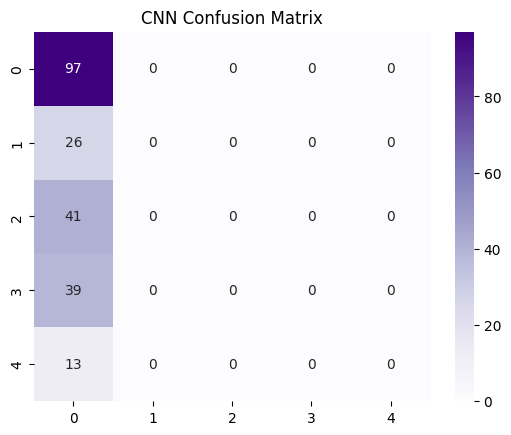

Epoch 1/25
34/34 - 4s - 123ms/step - accuracy: 0.4667 - loss: 1.2496 - learning_rate: 2.5000e-04
Epoch 2/25


c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


34/34 - 3s - 86ms/step - accuracy: 0.4796 - loss: 1.2187 - learning_rate: 2.5000e-04
Epoch 3/25
34/34 - 3s - 87ms/step - accuracy: 0.4750 - loss: 1.2138 - learning_rate: 2.5000e-04
Epoch 4/25
34/34 - 3s - 86ms/step - accuracy: 0.4991 - loss: 1.1944 - learning_rate: 2.5000e-04
Epoch 5/25
34/34 - 3s - 86ms/step - accuracy: 0.5287 - loss: 1.1764 - learning_rate: 2.5000e-04
Epoch 6/25
34/34 - 3s - 86ms/step - accuracy: 0.4981 - loss: 1.1712 - learning_rate: 2.5000e-04
Epoch 7/25
34/34 - 3s - 86ms/step - accuracy: 0.5148 - loss: 1.1612 - learning_rate: 2.5000e-04
Epoch 8/25
34/34 - 3s - 86ms/step - accuracy: 0.5231 - loss: 1.1456 - learning_rate: 2.5000e-04
Epoch 9/25
34/34 - 4s - 103ms/step - accuracy: 0.5269 - loss: 1.1289 - learning_rate: 2.5000e-04
Epoch 10/25
34/34 - 3s - 97ms/step - accuracy: 0.5324 - loss: 1.1147 - learning_rate: 2.5000e-04
Epoch 11/25
34/34 - 3s - 93ms/step - accuracy: 0.5556 - loss: 1.1052 - learning_rate: 2.5000e-04
Epoch 12/25
34/34 - 3s - 96ms/step - accuracy: 0

In [71]:
# Obtaining the height and width of the retinal images
# The images_train has shape (N, 28, 28, 3),  so we extract dimensions 1 and 2
Height = images_train.shape[1]
Width = images_train.shape[2]

# Normalize images to stabilize CNN training and reshape y 
# Convert uint8 to float32
X_cnn = images_train.astype("float32") / 255.0
y_cnn = labels_train.reshape(-1)
X_test_cnn = images_test.astype("float32") / 255.0

# Conduct the train_test_split 
X_tr_img, X_val_img, y_tr_img, y_val_img = train_test_split(
    X_cnn, y_cnn, test_size=0.2, stratify=y_cnn, random_state=42
)

# Define cnn training 
def cnn_train(X_tr_img, y_tr_img, X_val_img, y_val_img, Height, Width):
    # Set up try block 
    try:
        # Define the number of classes, it should be 5
        num_classes = len(np.unique(y_tr_img))

        # Stronger CNN architecture with 28 x 28 RGB images 
        model = models.Sequential([
            layers.Input(shape=(Height, Width, 3)),
            
            # Define Block 1 
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            # Batch Normalization is used to stabilize activations 
            layers.BatchNormalization(),
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            # This reduces spatial size 
            layers.MaxPooling2D(2,2),

            # Define Block 2 
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            
            # Define Block 3
            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            # This serves to compress the features 
            layers.GlobalAveragePooling2D(), 
            
            # Define Block 4
            # Preventing overfitting 
            layers.Dropout(0.4),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax")
        ])

        # The model compiles with the Adam Optimizer and the cross entropy loss
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        # Training on CNN
        print("\nTraining CNN ")

        # Adding EarlyStopping to prevent overfitting 
        # ReduceLROnPlateau which lowers LR when validation accuracy has plateauded        
        model_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                patience=4, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                factor=0.5, patience=2, min_lr=1e-5)
        ]
       # Fitting the model with the data 
        model.fit(
            X_tr_img, y_tr_img,
            validation_data=(X_val_img, y_val_img),
            epochs=25,
            batch_size=32,
            callbacks=model_callbacks,
            verbose=2
        )

        # Generating validation accuracy
        y_pred_val = np.argmax(model.predict(X_val_img), axis=1)
        val_acc = (y_pred_val == y_val_img).mean()
        val_error = 1 - val_acc
        
        # Printing Validation Accuracy 
        print("\nValidation Accuracy:", val_acc)
        print("\nError:", val_error)
        
        # Generating confusion matrix 
        cm = confusion_matrix(y_val_img, y_pred_val)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
        plt.title("CNN Confusion Matrix")
        plt.show()

        # Train on full dataset with callbacks
        model.fit(X_cnn, y_cnn, epochs=25, batch_size=32,
                  callbacks=model_callbacks, verbose=2)
        
        # Predicting y test 
        y_test_pred = np.argmax(model.predict(X_test_cnn), axis=1)

        pd.DataFrame({
            "ID": np.arange(1, len(y_test_pred)+1),
            "Label": y_test_pred
        }).to_csv("cnn_postNov30_NFE_submission.csv", index=False)

        print("Saved cnn_postNov30_NFE_submission.csv!")
        # Returning validation accuracy, validation error 
        return val_acc, val_error
    # Exception handling 
    except Exception as excep:
        print("There is an error in CNN:", str(excep))


# Calling cnn_train 
acc_cnn, err_cnn = cnn_train(X_tr_img, y_tr_img, X_val_img, y_val_img, Height, Width)


**CNN with Preprocessing with Feature Engineering**
This method beats the Kaggle baseline with a score of 49%. 


Training CNN model
Epoch 1/25
27/27 - 7s - 245ms/step - accuracy: 0.4426 - loss: 1.3673 - val_accuracy: 0.4528 - val_loss: 1.4738 - learning_rate: 0.0010
Epoch 2/25
27/27 - 2s - 91ms/step - accuracy: 0.4923 - loss: 1.2804 - val_accuracy: 0.4528 - val_loss: 1.4264 - learning_rate: 0.0010
Epoch 3/25
27/27 - 2s - 92ms/step - accuracy: 0.4923 - loss: 1.2397 - val_accuracy: 0.4528 - val_loss: 1.4365 - learning_rate: 0.0010
Epoch 4/25
27/27 - 2s - 92ms/step - accuracy: 0.5006 - loss: 1.2154 - val_accuracy: 0.4528 - val_loss: 1.6322 - learning_rate: 0.0010
Epoch 5/25
27/27 - 2s - 92ms/step - accuracy: 0.5349 - loss: 1.1531 - val_accuracy: 0.4528 - val_loss: 1.6077 - learning_rate: 5.0000e-04
Epoch 6/25
27/27 - 3s - 99ms/step - accuracy: 0.5266 - loss: 1.1434 - val_accuracy: 0.4528 - val_loss: 1.7150 - learning_rate: 5.0000e-04
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

This is the Validation Accuracy: 0.4528301886792453


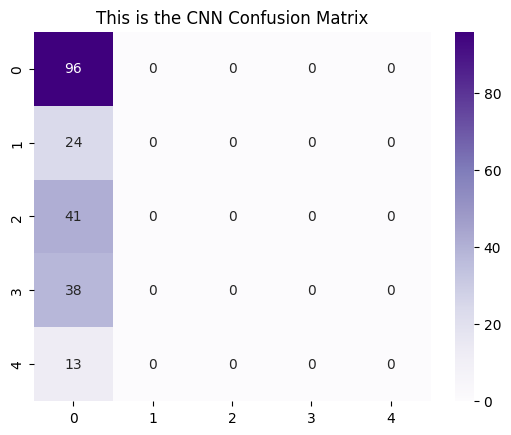

Epoch 1/25
34/34 - 3s - 93ms/step - accuracy: 0.4863 - loss: 1.2466 - learning_rate: 2.5000e-04
Epoch 2/25


c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\keras\src\callbacks\early_stopping.py:99: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)
c:\Users\Dell\OneDrive\Desktop\UdeM Graduate\Foundations of ML\Competition_2\venv_tf\lib\site-packages\keras\src\callbacks\callback_list.py:171: UserWarning: Learning rate reduction is conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss,learning_rate.
  callback.on_epoch_end(epoch, logs)


34/34 - 4s - 114ms/step - accuracy: 0.4976 - loss: 1.2246 - learning_rate: 2.5000e-04
Epoch 3/25
34/34 - 4s - 110ms/step - accuracy: 0.5109 - loss: 1.1919 - learning_rate: 2.5000e-04
Epoch 4/25
34/34 - 4s - 115ms/step - accuracy: 0.5005 - loss: 1.1870 - learning_rate: 2.5000e-04
Epoch 5/25
34/34 - 4s - 103ms/step - accuracy: 0.5270 - loss: 1.1617 - learning_rate: 2.5000e-04
Epoch 6/25
34/34 - 3s - 99ms/step - accuracy: 0.5213 - loss: 1.1655 - learning_rate: 2.5000e-04
Epoch 7/25
34/34 - 3s - 95ms/step - accuracy: 0.5412 - loss: 1.1426 - learning_rate: 2.5000e-04
Epoch 8/25
34/34 - 4s - 105ms/step - accuracy: 0.5383 - loss: 1.1261 - learning_rate: 2.5000e-04
Epoch 9/25
34/34 - 3s - 99ms/step - accuracy: 0.5430 - loss: 1.1085 - learning_rate: 2.5000e-04
Epoch 10/25
34/34 - 3s - 96ms/step - accuracy: 0.5525 - loss: 1.1053 - learning_rate: 2.5000e-04
Epoch 11/25
34/34 - 3s - 96ms/step - accuracy: 0.5374 - loss: 1.0770 - learning_rate: 2.5000e-04
Epoch 12/25
34/34 - 3s - 97ms/step - accurac

In [72]:
# Obtaining the height and width of the retinal images
# The images_train has shape (N, 28, 28, 3),  so we extract dimensions 1 and 2
Height = images_train_updated.shape[1]
Width = images_train_updated.shape[2]

# Normalize images to stabilize CNN training and reshape y 
# Convert uint8 to float32
X_cnn = images_train_updated.astype("float32") / 255.0
y_cnn = labels_train_updated.reshape(-1)
X_test_cnn = images_test.astype("float32") / 255.0

# Defining train test split 
X_tr_img, X_val_img, y_tr_img, y_val_img = train_test_split(
    X_cnn, y_cnn, test_size=0.2, stratify=y_cnn, random_state=42
)


def cnn_train(X_tr_img, y_tr_img, X_val_img, y_val_img, Height, Width):
    try:
        # Getting number of classes, this should be five 
        num_classes = len(np.unique(y_tr_img))

        # Stronger CNN architecture with 28 x 28 RBG images 
        model = models.Sequential([
            layers.Input(shape=(Height, Width, 3)),
            # Defining Batch 1 with relu activation
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            # Batch Normalization is used to stabilize activations 
            layers.BatchNormalization(),
            layers.Conv2D(32, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            
            # Defining Batch 2 with relu activation
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.Conv2D(64, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            layers.MaxPooling2D(2,2),
            
            # Defining Batch 3 with relu activation
            layers.Conv2D(128, 3, padding="same", activation="relu"),
            layers.BatchNormalization(),
            # This is used to compress the features 
            layers.GlobalAveragePooling2D(),
            
            layers.Dropout(0.4),
            layers.Dense(128, activation="relu"),
            layers.Dense(num_classes, activation="softmax")
        ])

        # Defining the model with Adam optimizer and sparse categorical cross entropy loss
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
            loss="sparse_categorical_crossentropy",
            metrics=["accuracy"]
        )
        # Defining Training CNN model 
        print("\nTraining CNN model")

        # Adding EarlyStopping to prevent overfitting 
        # ReduceLROnPlateau which lowers LR when validation accuracy has plateauded
        model_callbacks = [
            tf.keras.callbacks.EarlyStopping(
                patience=4, restore_best_weights=True),
            tf.keras.callbacks.ReduceLROnPlateau(
                factor=0.5, patience=2, min_lr=1e-5)
        ]
        # Fitting the Model on training data 
        model.fit(
            X_tr_img, y_tr_img,
            validation_data=(X_val_img, y_val_img),
            # Setting epochs and batch_size to 25 and 32 to avoid overfitting 
            epochs=25,
            batch_size=32,
            callbacks=model_callbacks,
            verbose=2
        )

        # Setting up validation accuracy and validation_error
        y_pred_val = np.argmax(model.predict(X_val_img), axis=1)
        val_acc = (y_pred_val == y_val_img).mean()
        val_error = 1 - val_acc

        # Printing the validation accuracy 
        print("\nThis is the Validation Accuracy:", val_acc)
        
        # Defining and generating confusion matrix 
        cm = confusion_matrix(y_val_img, y_pred_val)
        sns.heatmap(cm, annot=True, fmt="d", cmap="Purples")
        plt.title("This is the CNN Confusion Matrix")
        plt.show()

        # Training on the full dataset with callbacks
        # Fitting the model with given epochs and batch_size 
        model.fit(X_cnn, y_cnn, epochs=25, batch_size=32,
                  callbacks=model_callbacks, verbose=2)
        # Define y_test predictions on X_test 
        y_test_pred = np.argmax(model.predict(X_test_cnn), axis=1)
        
        # Define the Data Frame which will be used for the kaggle submission file 
        pd.DataFrame({
            "ID": np.arange(1, len(y_test_pred)+1),
            "Label": y_test_pred
        }).to_csv("cnn_postNov30_FE_submission.csv", index=False)
        # Printing the cnn Nov 30th submission statement 
        print("Saved cnn_postNov30_FE_submission.csv!")
        # Returning the val_acc and val_error
        return val_acc, val_error
    # Exception handling 
    except Exception as excep:
        print("There is an exception in the CNN model:", str(excep))


# Defining acc_cnn and err_cnn through calling cnn_train 
acc_cnn, err_cnn = cnn_train(X_tr_img, y_tr_img, X_val_img, y_val_img, Height, Width)
